# Principal and Agent

Here, we will work a few simple principal-agent problems using some simple assumptions, with the ultimate aim of figuring out how **[this paper](https://www.aeaweb.org/articles?id=10.1257/aer.20220100)** works. To start, let's pick it up with the cost of effort function, which depends on type. $a$ is effort, $\theta$ is type, and $c(a,\theta)$ are costs of effort. 

Requirements are:

$$
c(0,\theta)=0,c_a>0,c_{aa}>0,c_\theta<0,c_{a\theta}<0,c_{aa\theta}\leq 0 c_{a\theta\theta} \geq 0
$$

So, a potential cost function is:

$$
c(a,\theta) = \frac{a^2}{2\theta}
$$

Let's check, and get the symbolic engine rolling.

In [5]:
from sympy import *

In [6]:
a, theta = symbols('a theta')

In [7]:
c = a**2/(2*theta)

In [12]:
diff(c,a), diff(c, a, a), diff(c, theta), diff(c, a, theta), diff(c, a, a, theta), diff(c, a, theta, theta)

(a/theta, 1/theta, -a**2/(2*theta**2), -a/theta**2, -1/theta**2, 2*a/theta**3)

### Two-point outcomes

We will also assume that there are good and bad outcomes, which occur with probability $p=\delta a$ and $p'=(1-\delta a)$, where we have to assume that $\delta$ is sufficiently small. We should now be able to figure out, given type, and action, what the lowest cost of implementing any action, under the first-order condition criterion. Suppose the agent gets utility $u_g$ when outcomes are good, and $u_b$ when outcomes are bad. The constraints are:

##### Participation
$$
u_g \delta a + (1-\delta a) u_b - \frac{a^2}{2\theta} \geq u_0
$$

##### Incentive Compatibility (FOC)
$$
\delta (u_g-u_b)\theta= a
$$

Suppose utility is $u=w^\alpha$, $\alpha<1$. Then, we have: $w=u^{\frac{1}{\alpha}}$. So, what are the costs of implementing a particular value of $\alpha$? We need to solve the above constraints for $u_g$ and $u_b$, so let's do this as follows:

In [29]:
ug, ub, u0, delta, alpha = symbols('u_g u_b u_0 delta alpha')

In [30]:
part = ug*delta*a + (1-delta)*ub - a**2/(2*theta) - u0
icom = delta*(ug-ub)*theta - a

In [31]:
solns = solve([part, icom], [ug, ub])

In [32]:
ubsta = solns[ub].simplify()
ugsta = solns[ug].simplify()

In [33]:
ubsta

(-a**2/2 + theta*u_0)/(theta*(a*delta - delta + 1))

Okay, now what we do, is plug this into the payment function for the principal:

In [42]:
Costnrf = delta*a*ug**(1/alpha) + (1-delta*a)*ub**(1/alpha)

In [43]:
Cost = Costnrf.subs({ug:ugsta, ub:ubsta}).simplify()

Which I think fits the bill - it depends upon $a$, $\theta$, and $u_0$. It's hard to get a feel for this, so let's see what happens when we substitute in for some of the parameters:

In [44]:
Cost

a*delta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*delta*theta*(a*delta - delta + 1)))**(1/alpha) + ((-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)))**(1/alpha)*(-a*delta + 1)

In [56]:
Costex = Cost.subs({alpha:1}).simplify()
Costex

(a**3*delta - a**2*delta + a**2/2 + theta*u_0)/(theta*(a*delta - delta + 1))

In [71]:
Cost1 = Costex.subs({delta:.025, theta:1, u0:1})
Cost2 = Costex.subs({delta:.025, theta:2, u0:1})
Cost3 = Costex.subs({delta:.025, theta:3, u0:1})

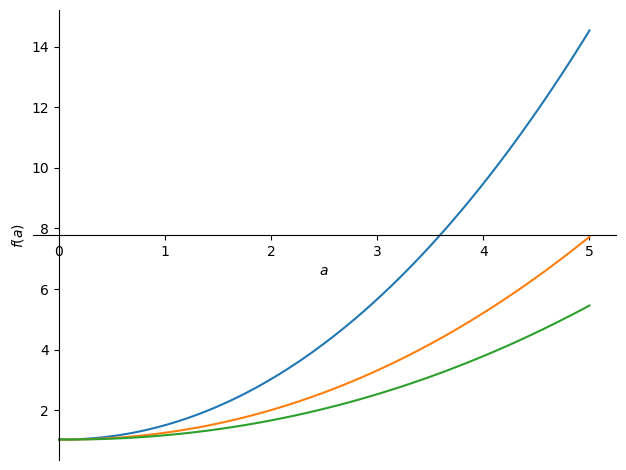

In [72]:
plot(Cost1, Cost2, Cost3, (a, 0, 5))

So, we see how costs bend as we move from lower to higher values for $\theta$. 

### The relaxed problem

What happens next, now that we have the minimum costs of implementing any action?  We require that any agent that gives us his actual type should follow his first-order condition. We define the surplus for a type $\theta$ agent as:

$$
\delta a u_g + (1-\delta a)u_b - \frac{ca^2}{2\theta}
$$